# Plot multi-lead predictions for predicting hurricane track (distance) errors.
author: Elizabeth A. Barnes and Randal J. Barnes

In [1]:
%matplotlib inline
%load_ext autotime

import sys
import importlib as imp
import warnings
from shapely.errors import ShapelyDeprecationWarning

warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from scipy.stats import multivariate_normal
from silence_tensorflow import silence_tensorflow
import pandas as pd
import cartopy as ct
import plots

import experiment_settings
import mahalanobis
from build_data import build_data
import data_info

time: 2.01 s (started: 2022-11-04 13:39:40 -06:00)


In [2]:
__author__ = "Randal J Barnes and Elizabeth A. Barnes"
__version__ = "16 September 2022"

silence_tensorflow()
tf.config.set_visible_devices([], "GPU")  # turn-off tensorflow-metal if it is on

DATA_PATH = "data/"
MODEL_PATH = "saved_models/"
FIGURE_PATH = "figures/analysis/"

time: 440 µs (started: 2022-11-04 13:39:42 -06:00)


In [3]:
plt.style.use("seaborn-white")
mpl.rcParams['savefig.dpi'] = 300
mpl.rcParams["figure.dpi"] = 100
dpiFig = 300
plots.set_plot_rc()
np.warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)

time: 454 µs (started: 2022-11-04 13:39:42 -06:00)


In [4]:
EXP_NAME_VEC = (
    "centered_bivariate_normal_100_EPCP12",
    "centered_bivariate_normal_101_EPCP24",
    "centered_bivariate_normal_102_EPCP36",
    "centered_bivariate_normal_103_EPCP48",
    "centered_bivariate_normal_104_EPCP60",
    "centered_bivariate_normal_105_EPCP72",
    "centered_bivariate_normal_106_EPCP84",
    "centered_bivariate_normal_107_EPCP96",
    "centered_bivariate_normal_108_EPCP108",
    "centered_bivariate_normal_109_EPCP120",
    )

RNG_SEED = 1
TESTING_YEAR = 2018
LONGITUDE_SCALING = 1.  #all longitudes are in degrees east in the dataset

time: 303 µs (started: 2022-11-04 13:39:42 -06:00)


In [5]:
# GET PREDICTIONS
df_pred_train = pd.DataFrame()
df_pred_valtest = pd.DataFrame()
df_pred_test = pd.DataFrame()

for exp_name in EXP_NAME_VEC:
    print(exp_name)
    settings = experiment_settings.get_settings(exp_name)

    settings["rng_seed"] = RNG_SEED
    settings["years_test"] = (TESTING_YEAR,)
    try:
        (
            data_summary,
            x_train,
            onehot_train,
            x_val,
            onehot_val,
            x_test,
            onehot_test,
            x_valtest,
            onehot_valtest,
            df_train,
            df_val,
            df_test,
            df_valtest,
            ) = build_data(DATA_PATH, settings, verbose=0)
    except:
        continue

    # load the model
    model_name = (
            exp_name
            + "_"
            + str(TESTING_YEAR)
            + "_"
            + settings["uncertainty_type"]
            + "_"
            + f"rng_seed_{settings['rng_seed']}"
    )
    try:
        model = tf.keras.models.load_model(MODEL_PATH + model_name + "_model", compile=False)
    except:
        continue

    # make dictionary of the predictions
    pred_dict_lead = {
        "exp_name": exp_name,
        "testing_year": TESTING_YEAR,
        }

    # copy dataframe and fill in the predictions
    df_train_lt = df_train.copy()
    df_valtest_lt = df_valtest.copy()
    df_test_lt = df_test.copy()

    df_train_lt[["mu_u", "mu_v", "sigma_u", "sigma_v", "rho"]] = model.predict(x_train)
    df_valtest_lt[["mu_u", "mu_v", "sigma_u", "sigma_v", "rho"]] = model.predict(x_valtest)
    # df_test_lt[["mu_u", "mu_v", "sigma_u", "sigma_v", "rho"]] = model.predict(x_test)
    try:
        df_test_lt[["mu_u", "mu_v", "sigma_u", "sigma_v", "rho"]] = model.predict(x_test)
    except:
        df_test_lt[["mu_u", "mu_v", "sigma_u", "sigma_v", "rho"]] = np.nan

    df_train_lt["exp_name"] = exp_name
    df_valtest_lt["exp_name"] = exp_name
    df_test_lt["exp_name"] = exp_name

    # correct longitude for the Atlantic or Pacific
    df_train_lt["LONC"] = df_train_lt["LONC"] * LONGITUDE_SCALING
    df_valtest_lt["LONC"] = df_valtest_lt["LONC"] * LONGITUDE_SCALING
    df_test_lt["LONC"] = df_test_lt["LONC"] * LONGITUDE_SCALING

    # append to main dataframe
    df_pred_train = pd.concat([df_pred_train, df_train_lt], axis=0)
    df_pred_valtest = pd.concat([df_pred_valtest, df_valtest_lt], axis=0)
    df_pred_test = pd.concat([df_pred_test, df_test_lt], axis=0)

centered_bivariate_normal_100_EPCP12
centered_bivariate_normal_101_EPCP24
centered_bivariate_normal_102_EPCP36
centered_bivariate_normal_103_EPCP48
centered_bivariate_normal_104_EPCP60
centered_bivariate_normal_105_EPCP72
centered_bivariate_normal_106_EPCP84
centered_bivariate_normal_107_EPCP96
centered_bivariate_normal_108_EPCP108
centered_bivariate_normal_109_EPCP120
time: 3.87 s (started: 2022-11-04 13:39:42 -06:00)


# Plot Results

In [6]:
df_pred_test

,ATCF,Name,year,time,ftime(hr),VMAX0,NCI,OFDV,OBDV,DSDV,...,HWDY,LATC,PREDICTAND_X,PREDICTAND_Y,mu_u,mu_v,sigma_u,sigma_v,rho,exp_name
0,EP14,LANE,2018,82200,12,135.0,4,-5.0,3.2,3.2,...,8.3,15.0,0.0,-22.2,-0.0,0.0,24.600418,24.629356,-0.020984,centered_bivariate_normal_100_EPCP12
1,EP16,NORMAN,2018,83018,12,130.0,4,-10.0,-1.2,4.8,...,-8.3,17.3,10.6,-11.1,-0.0,0.0,24.600418,24.629356,-0.020984,centered_bivariate_normal_100_EPCP12
2,EP17,OLIVIA,2018,90800,12,85.0,4,-5.0,1.2,0.2,...,-13.9,21.3,0.0,11.1,-0.0,0.0,24.600418,24.629356,-0.020984,centered_bivariate_normal_100_EPCP12
3,EP13,KRISTY,2018,80812,12,40.0,4,5.0,7.5,1.5,...,16.7,15.1,21.5,-11.1,-0.0,0.0,36.180988,35.196568,0.017483,centered_bivariate_normal_100_EPCP12
4,EP13,KRISTY,2018,80906,12,40.0,4,10.0,10.5,-1.5,...,-11.1,16.6,10.7,0.0,-0.0,0.0,34.074345,33.284515,0.010378,centered_bivariate_normal_100_EPCP12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,EP16,NORMAN,2018,90118,120,90.0,4,35.0,31.8,-1.2,...,333.3,22.0,-103.3,-133.3,-0.0,0.0,164.759521,133.020798,0.209123,centered_bivariate_normal_109_EPCP120
191,EP10,HECTOR,2018,80812,120,110.0,4,-40.0,-27.2,14.8,...,155.5,24.1,0.0,233.3,-0.0,0.0,155.393738,123.520889,0.204178,centered_bivariate_normal_109_EPCP120
192,EP10,HECTOR,2018,80300,120,95.0,4,20.0,37.0,8.0,...,52.8,16.8,-53.3,-11.1,-0.0,0.0,183.441864,151.294662,0.209529,centered_bivariate_normal_109_EPCP120
193,EP14,LANE,2018,81618,120,60.0,4,40.0,50.8,4.8,...,177.8,15.2,-21.5,-133.3,-0.0,0.0,218.415222,187.320618,0.216445,centered_bivariate_normal_109_EPCP120


time: 12.8 ms (started: 2022-11-04 13:39:46 -06:00)


60 dataframe is empty
84 dataframe is empty
108 dataframe is empty


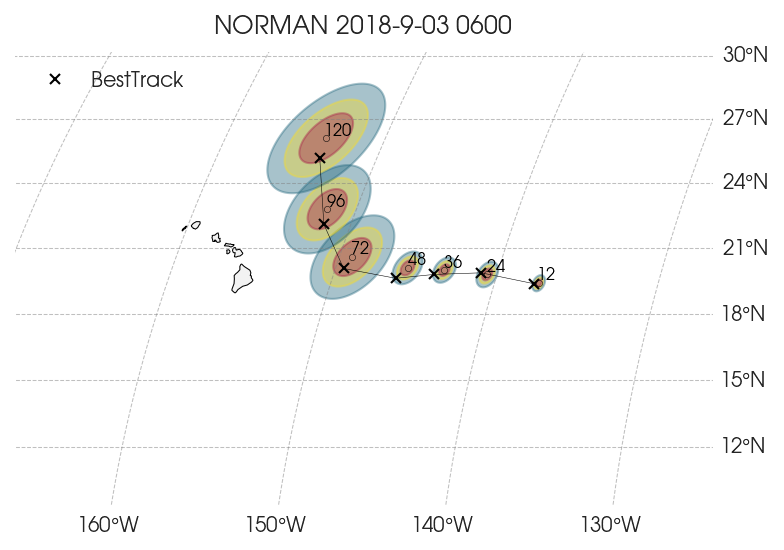

time: 8.71 s (started: 2022-11-04 13:39:46 -06:00)


In [7]:
imp.reload(mahalanobis)
imp.reload(plots)

fig = plt.figure(dpi=150, )
ax = fig.add_subplot(1, 1, 1, projection=ct.crs.EqualEarth(central_longitude=0.))

# storm = {
#     "storm_name": "PALI",
#     "pred_time": 10812,
#     "extent": [195, 360-135, 5, 35],
#     }

storm = {
    "storm_name": "NORMAN",
    "pred_time": 90306,
    "extent": [195, 360-135, 5, 35],
    }
# storm = {"storm_name": "MICHAEL",
#          "pred_time": 100718,
#          "extent": [-100,-70,15,45],
#          }

df_storm = df_pred_test.loc[
    (df_pred_test["Name"] == storm["storm_name"]) & (df_pred_test["time"] == storm["pred_time"])]
details = plots.plot_leadtime_predictions(
    df_storm,
    ax=ax,
    leadtimes=np.arange(12,120+12, 12),
    contours=(.25, .5, .75,),
    )
# ax.set_global()
ax.set_extent(storm["extent"], crs=ct.crs.PlateCarree())

# save the figure
plt.savefig(
    FIGURE_PATH + 'multi_lead_predictions_' + EXP_NAME_VEC[0] + '_' + details.replace(' ', '_') + '.png',
    dpi=dpiFig,
    bbox_inches='tight',
    )
plt.show()

In [8]:
df_storm

,ATCF,Name,year,time,ftime(hr),VMAX0,NCI,OFDV,OBDV,DSDV,...,HWDY,LATC,PREDICTAND_X,PREDICTAND_Y,mu_u,mu_v,sigma_u,sigma_v,rho,exp_name
252,EP16,NORMAN,2018,90306,12,110.0,4,-5.0,-7.0,2.0,...,8.3,19.4,-31.4,-11.1,-0.0,0.0,24.600418,24.629356,-0.020984,centered_bivariate_normal_100_EPCP12
414,EP16,NORMAN,2018,90306,24,110.0,4,-10.0,-12.5,1.5,...,30.6,19.8,-62.7,-11.1,-0.0,0.0,41.243599,39.222248,0.018737,centered_bivariate_normal_101_EPCP24
229,EP16,NORMAN,2018,90306,36,110.0,4,-10.0,-9.5,-1.5,...,44.4,20.0,-73.1,-44.4,-0.0,0.0,43.820644,38.633358,0.024243,centered_bivariate_normal_102_EPCP36
74,EP16,NORMAN,2018,90306,48,110.0,4,5.0,6.0,-5.0,...,80.5,20.1,-73.1,-88.9,-0.0,0.0,56.416489,49.922375,0.058387,centered_bivariate_normal_103_EPCP48
263,EP16,NORMAN,2018,90306,72,110.0,4,35.0,37.8,-8.2,...,186.1,20.6,-52.0,-122.2,-0.0,0.0,151.623581,127.581383,0.174716,centered_bivariate_normal_105_EPCP72
174,EP16,NORMAN,2018,90306,96,110.0,4,15.0,14.2,-10.8,...,333.3,22.8,-10.2,-155.5,-0.0,0.0,159.251907,135.980316,0.072595,centered_bivariate_normal_107_EPCP96
150,EP16,NORMAN,2018,90306,120,110.0,4,5.0,10.0,-7.0,...,383.3,26.1,0.0,-211.1,-0.0,0.0,202.456070,170.990448,0.213616,centered_bivariate_normal_109_EPCP120


time: 9.06 ms (started: 2022-11-04 13:39:54 -06:00)
